<a href="https://colab.research.google.com/github/ARMAAN15092007/25BAI0198_EDA/blob/main/EXP%209%20%7C%2015.09.2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from wordcloud import WordCloud
from scipy.cluster.hierarchy import dendrogram, linkage
from pandas.plotting import parallel_coordinates, andrews_curves


In [2]:
df = pd.read_csv('/content/ai_jobs_salaries_clean.csv')

In [3]:
def plot_pie(data, labels, title="Pie Chart"):
    plt.figure(figsize=(6, 6))
    plt.pie(data, labels=labels, autopct='%1.1f%%', startangle=140)
    plt.title(title)
    plt.show()

In [4]:
def plot_bar(categories, values, title="Bar Chart"):
    plt.figure(figsize=(10, 5))
    plt.bar(categories, values, color='skyblue')
    plt.title(title)
    plt.xticks(rotation=45)
    plt.show()

In [5]:
def plot_histogram(df, column):
    plt.figure(figsize=(8, 5))
    plt.hist(df[column].dropna(), bins=20, edgecolor='black', color='salmon')
    plt.title(f"Histogram of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

In [6]:
def heatmap(df, annot=True, cmap='coolwarm'):
    plt.figure(figsize=(8, 6))
    sns.heatmap(df, annot=annot, cmap=cmap)
    plt.title("Heat Map")
    plt.show()

In [7]:
def scatter(x, y):
    plt.figure(figsize=(8, 5))
    plt.scatter(x, y, alpha=0.5, color='purple')
    plt.title(f"Scatter Plot")
    plt.show()

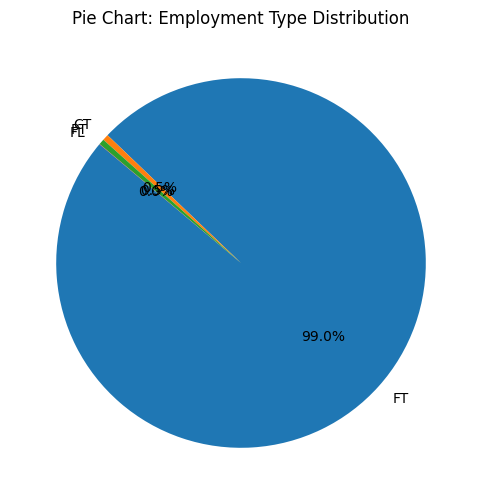

In [8]:
emp_counts = df['employment_type'].value_counts()
plot_pie(emp_counts.values, emp_counts.index, title="Pie Chart: Employment Type Distribution")


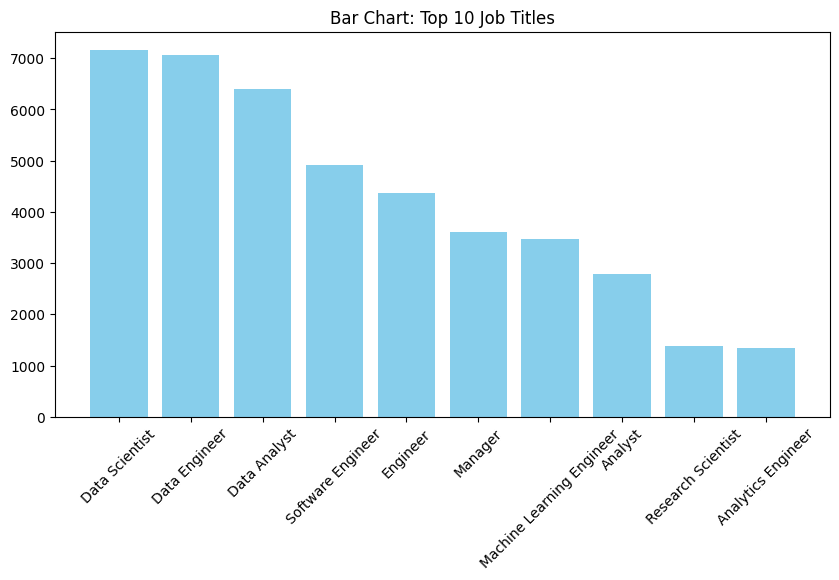

In [9]:
job_counts = df['job_title'].value_counts().head(10)
plot_bar(job_counts.index, job_counts.values, title="Bar Chart: Top 10 Job Titles")


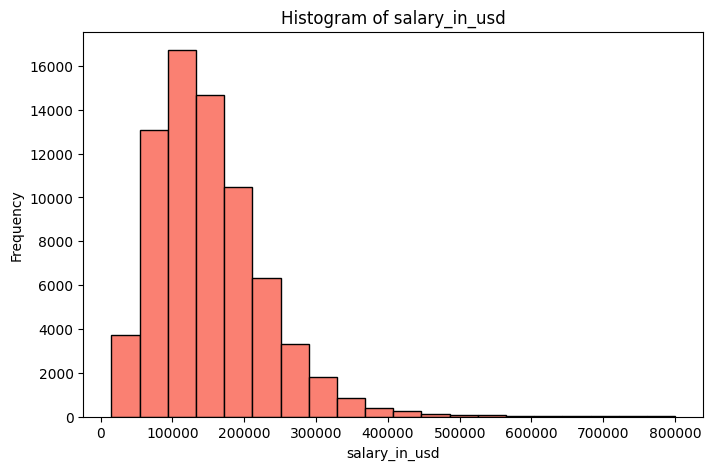

In [10]:
plot_histogram(df, 'salary_in_usd')

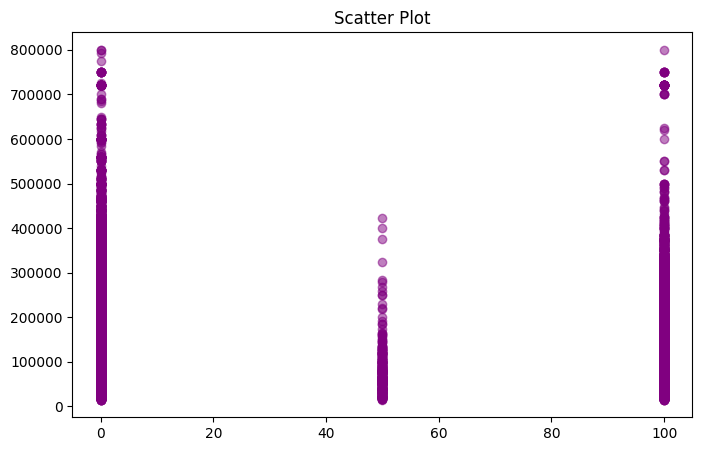

In [11]:
scatter(df['remote_ratio'], df['salary_in_usd'])

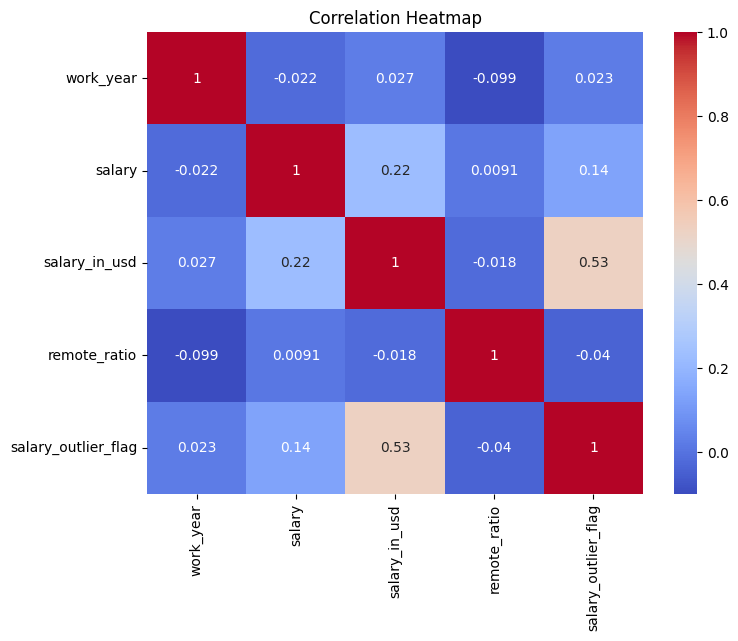

In [12]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

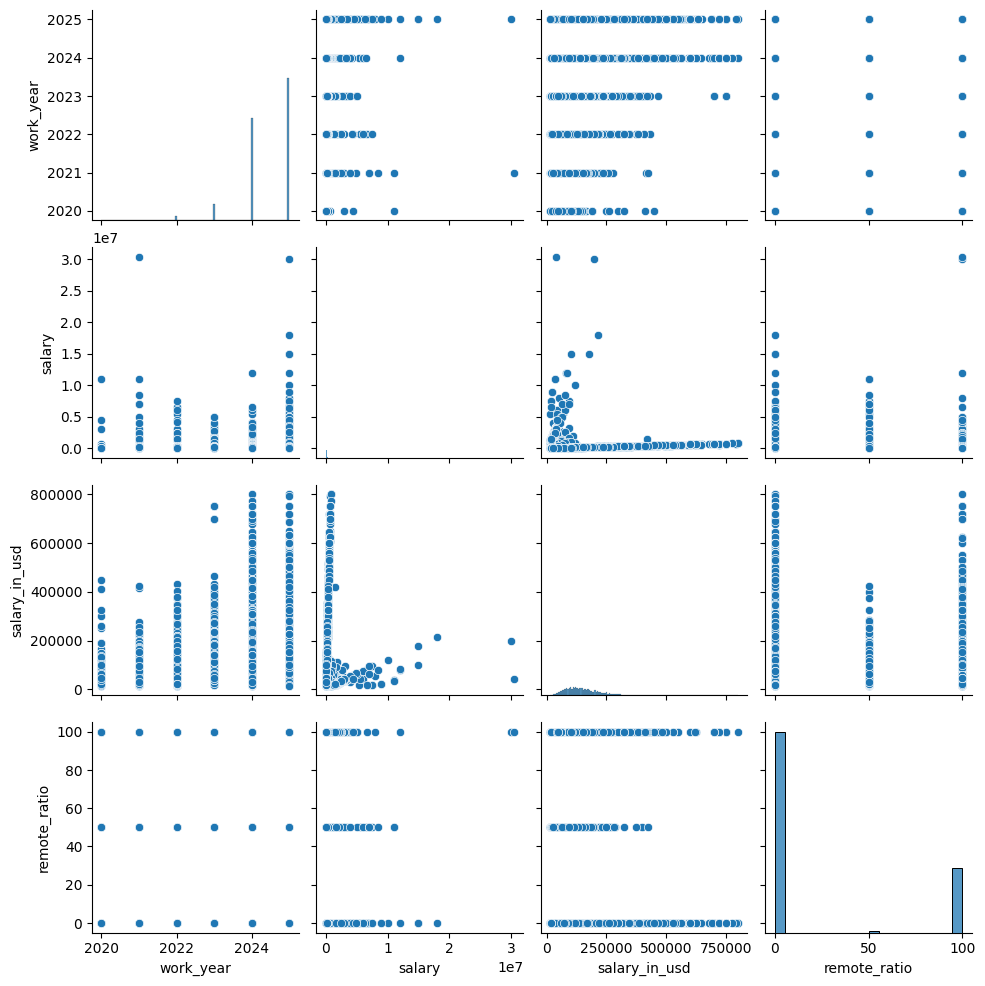

In [13]:
numeric_df = df.select_dtypes(include=[np.number])
sns.pairplot(df[numeric_df.columns])
plt.show()

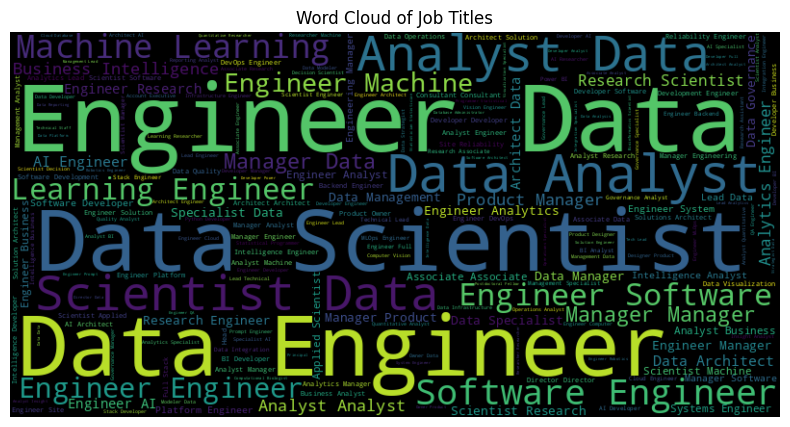

In [15]:
text = " ".join(review for review in df['job_title'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color='black').generate(text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of Job Titles")
plt.show()

In [16]:
geo_df = df.groupby('company_location')['salary_in_usd'].mean().reset_index()
fig = px.choropleth(geo_df, locations="company_location", locationmode='ISO-3',
                    color="salary_in_usd", title="Choropleth Map: Avg Salary")
fig.show()


In [18]:
print(df['company_location'].unique()[:10])


['US' 'CA' 'NL' 'FR' 'GB' 'DE' 'ES' 'IE' 'AU' 'LT']


In [20]:
!pip install pycountry


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 65.0 MB/s eta 0:00:00


In [21]:
import pycountry
import plotly.express as px

geo_df = df.groupby('company_location')['salary_in_usd'].mean().reset_index()

def convert_to_iso3(alpha_2):
    try:
        return pycountry.countries.get(alpha_2=alpha_2).alpha_3
    except:
        return None
geo_df['iso_alpha_3'] = geo_df['company_location'].apply(convert_to_iso3)
fig = px.choropleth(geo_df,
                    locations="iso_alpha_3",
                    locationmode='ISO-3',
                    color="salary_in_usd",
                    title="Choropleth Map: Avg Salary by Country",
                    color_continuous_scale=px.colors.sequential.Plasma)
fig.show()


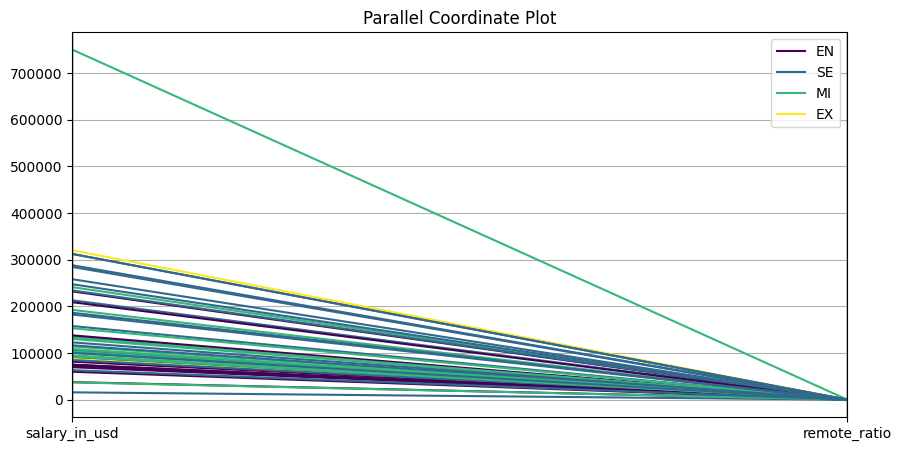

In [27]:
from pandas.plotting import parallel_coordinates
import matplotlib.pyplot as plt
sample_df = df.dropna().sample(n=min(50, len(df)), random_state=42) # For complex plots

plt.figure(figsize=(10, 5))
parallel_coordinates(sample_df[['experience_level', 'salary_in_usd', 'remote_ratio']], 'experience_level', colormap='viridis')
plt.title("Parallel Coordinate Plot")
plt.show()

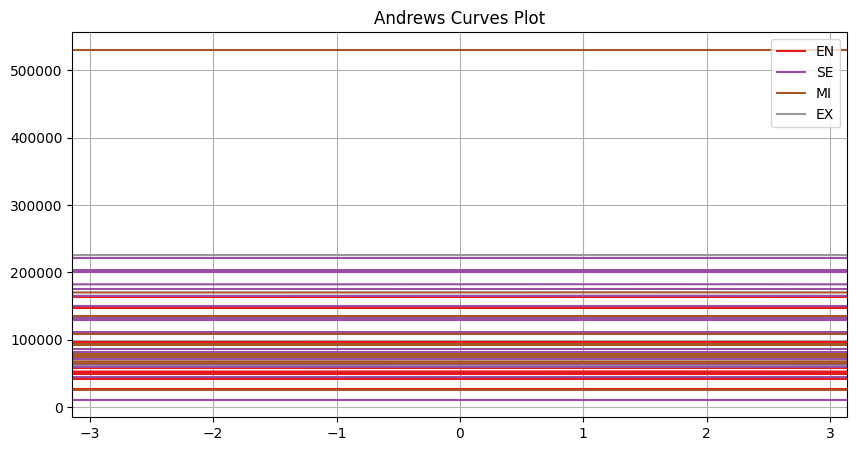

In [28]:
plt.figure(figsize=(10, 5))
andrews_curves(sample_df[['experience_level', 'salary_in_usd', 'remote_ratio']], 'experience_level', colormap='Set1')
plt.title("Andrews Curves Plot")
plt.show()

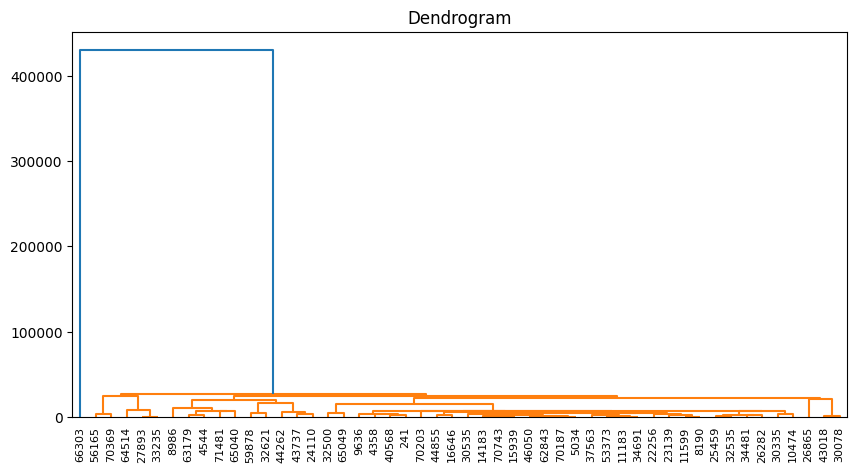

In [29]:
clustering_data = sample_df[['salary_in_usd', 'remote_ratio']].dropna()
linked = linkage(clustering_data, 'single')
plt.figure(figsize=(10, 5))
dendrogram(linked, labels=clustering_data.index.astype(str))
plt.title("Dendrogram")
plt.show()